In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("df_assignment.csv.gz", compression="gzip")

focus_crime = [
    "larceny theft",
    "motor vehicle theft",
    "robbery",
    "assault",
    "drug offense",
    "weapons offense",
    "vandalism",
    "suicide",
]

# remapping "malicious mischief" to "vandalism"
df.loc[df["category"] == "malicious mischief", "category"] = "vandalism"



In [26]:
# Filter to focus crimes only
df_focus = df[df["category"].isin(focus_crime)].copy()

# Dropping rows if any missing district info present
df_focus = df_focus.dropna(subset=["police_district"])

# Count crimes per district per category
counts = (
    df_focus.groupby(["police_district", "category"])
    .size()
    .unstack("category", fill_value=0)
)

for crime in focus_crime:
    if crime not in counts.columns:
        counts[crime] = 0

counts = counts[focus_crime]  # Reordering columns to match focus_crime order
# print(counts.shape)

**Computing the ratio according to the given formula**

In [27]:
district_totals = counts.sum(axis=1)  # Total crimes per district
profile = counts.div(district_totals, axis=0)  # P(crime | district)

# computing P(crime)
city_totals = counts.sum(axis=0)  # Total of each crime city-wide
grand_total = city_totals.sum()  # Grand total of all focus crimes
city_profile = city_totals / grand_total  # P(crime)

# computing the ratio
ratio_table = profile.div(city_profile, axis=1)

**Showing the ratios using heatmap**

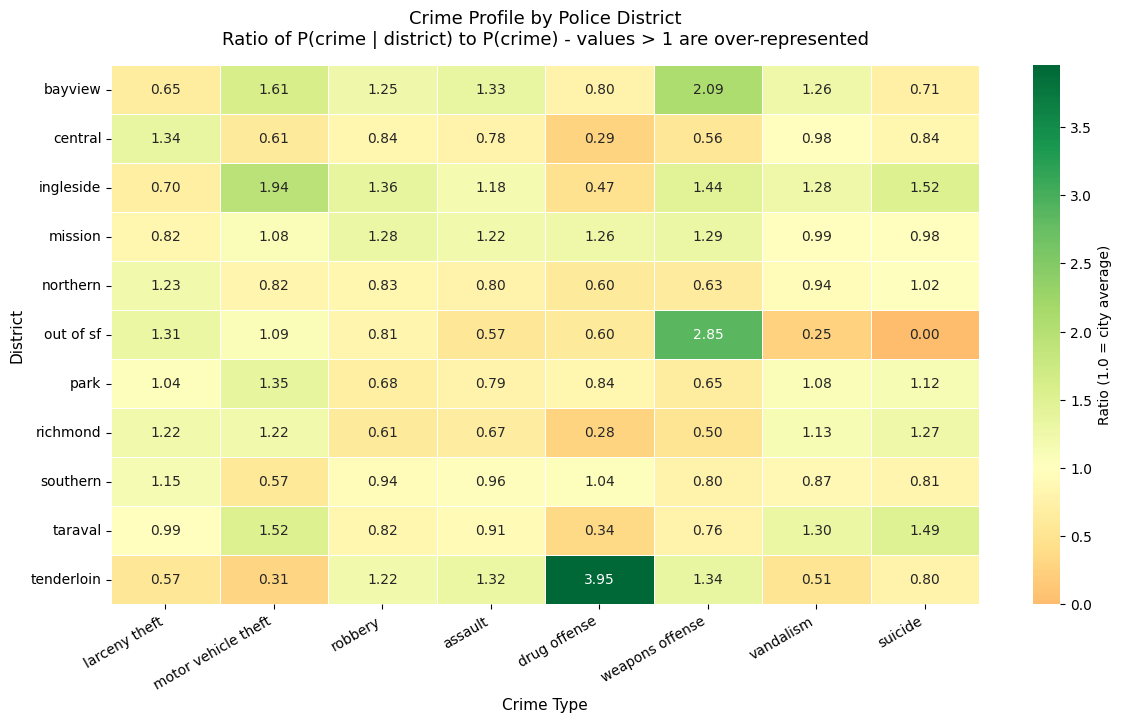

In [28]:
# showing in the  heatmap
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    ratio_table,
    cmap="RdYlGn",
    center=1.0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Ratio (1.0 = city average)"},
)

ax.set_title(
    "Crime Profile by Police District\n"
    "Ratio of P(crime | district) to P(crime) - values > 1 are over-represented",
    fontsize=13,
    pad=15,
)
ax.set_xlabel("Crime Type", fontsize=11)
ax.set_ylabel("District", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.show()

**Analysis from the heatmap:**

The most noticeable crime-profile in the San Francisco District Crime Ratio is in the Tenderloin District. As shown in the heat map, the drug offense ratio in the Tenderloin is 3.95, which is approximately four times higher than the San Francisco city-wide average for Drug Offenses, and the darkest cell on the heat map for all eleven districts and eight selected crime types. No other district/crime type combination has a higher ratio compared to the Tenderloin District. On the other hand, there are very few districts/crimes that have a lower ratio than those related to the theft of vehicles and residential targeting, with the lowest being 0.31 and 0.51, respectively, across all eight crime categories in the city.

The data from [ABC7 News (2022)](https://abc7news.com/post/sf-tenderloin-drug-arrests-narcan-homeless/11535735/) also shows that approximately 85% of all drug-related arrests in San Francisco occur in the Tenderloin district. In addition, the city has traditionally located addiction treatment centers, homeless shelters, and social service agencies within the Tenderloin district. Based on the information provided by this study, it is likely that the concentration of these services in the Tenderloin district may be one of the reasons why we found the ratio of drug offenses in the Tenderloin was almost four times greater than the city-wide average across 8 crime categories.

In contrast, the Tenderloin is an incredibly densely populated and relatively small 50-block neighborhood in downtown San Francisco. This area is known as one of the most walkable neighborhoods in the city and the most transit-rich area in San Francisco. Additionally, only 11% of households in certain portions of the Tenderloin own a car, and approximately 85% of all the homes in the Tenderloin have no vehicles ([SF Chronicle, 2025](https://www.sfchronicle.com/sf/article/car-ownership-by-neighborhood-20050210.php), [WalkSF (2018)](https://walksf.org/2018/02/02/designing-a-safer-taylor-street/). Therefore, obviously, there are fewer vehicles available for thieves to steal. This evidence supports our finding of an extremely low motor vehicle theft ratio of 0.31 in Tenderloin.

In summary, the high rate of drug offenses in the Tenderloin (3.95) isn't just a result of things that individuals choose to do; it is also a product of decades of policy decisions to concentrate social services, poverty, and at-risk populations in a very small geographic area. The increased police presence results in more arrests being recorded in this area. Combined with heavy policing, this creates a feedback loop, more arrests justify more police, which produces more arrests that increase the potential for bias. This is the exact type of bias that poses a threat to predictive policing tools. The data is based on where the police are looking, rather than where crime actually is.